#### Polar Coordinates
##### Position in Polar Coordinates
$\vec r=r\left(\begin{matrix}\cos(\theta)\\ \sin(\theta)\end{matrix}\right)$

##### Unit Vectors in Polar Coordinates
$\vec e_r=\left(\begin{matrix}\cos(\theta)\\ \sin(\theta)\end{matrix}\right)$

$\vec e_\theta=\left(\begin{matrix}-\sin(\theta)\\ \cos(\theta)\end{matrix}\right)$

##### Position in Polar Coordinates
$\vec r=r\vec e_r$

##### Time Derivatives of Unit Vectors in Polar Coordinates
$\dot{\vec e}_r=\left(\begin{matrix}-\sin(\theta)\\ \cos(\theta)\end{matrix}\right)\dot \theta =\dot \theta \vec e_\theta$

$\dot{\vec e}_\theta =\left(\begin{matrix}-\cos(\theta)\\ -\sin(\theta)\end{matrix}\right)\dot \theta =-\dot \theta \vec e_r$

##### Velocity in Polar Coordinates
$\vec v = \dot r\vec e_r+r\dot \theta\vec e_\theta$

##### Acceleration in Polar Coordinates
$\vec a = \left(\ddot r-r\dot \theta^2\right)\vec e_r+\left(r\ddot \theta+2\dot r\dot\theta\right)\vec e_r$


##### Derivation of derivatives of unit vectors

In [20]:
import sympy as sp
t = sp.symbols('t')
r = sp.Function('r')(t)
theta = sp.Function('theta')(t)
e_r = sp.Matrix([sp.cos(theta),sp.sin(theta)])
e_theta = sp.Matrix([-sp.sin(theta),sp.cos(theta)])
display(e_r.diff(t))
display(e_theta.diff(t))
# check that the results are correct
display(e_r.diff(t)-theta.diff(t)*e_theta)
display(e_theta.diff(t)-(-theta.diff(t)*e_r))


Matrix([
[-sin(theta(t))*Derivative(theta(t), t)],
[ cos(theta(t))*Derivative(theta(t), t)]])

Matrix([
[-cos(theta(t))*Derivative(theta(t), t)],
[-sin(theta(t))*Derivative(theta(t), t)]])

Matrix([
[0],
[0]])

Matrix([
[0],
[0]])

##### Derivation of expressions for position, velocity, and acceleration

In [25]:
import sympy as sp
t = sp.symbols('t')
r = sp.Function('r')(t)
theta = sp.Function('theta')(t)
pos = sp.Matrix([r*sp.cos(theta),r*sp.sin(theta)])
vel = pos.diff(t)
acc = vel.diff(t)
display(pos,vel,acc)


Matrix([
[r(t)*cos(theta(t))],
[r(t)*sin(theta(t))]])

Matrix([
[-r(t)*sin(theta(t))*Derivative(theta(t), t) + cos(theta(t))*Derivative(r(t), t)],
[ r(t)*cos(theta(t))*Derivative(theta(t), t) + sin(theta(t))*Derivative(r(t), t)]])

Matrix([
[-r(t)*sin(theta(t))*Derivative(theta(t), (t, 2)) - r(t)*cos(theta(t))*Derivative(theta(t), t)**2 - 2*sin(theta(t))*Derivative(r(t), t)*Derivative(theta(t), t) + cos(theta(t))*Derivative(r(t), (t, 2))],
[-r(t)*sin(theta(t))*Derivative(theta(t), t)**2 + r(t)*cos(theta(t))*Derivative(theta(t), (t, 2)) + sin(theta(t))*Derivative(r(t), (t, 2)) + 2*cos(theta(t))*Derivative(r(t), t)*Derivative(theta(t), t)]])

##### Newtons Second Law of Motion in Polar Coordinates
$m\left(\ddot r-r\dot \theta^2\right)=F_r$

$m\left(r\ddot \theta+2\dot r\dot\theta\right)=F_\theta$

where $F_r$ is the sum of force components in the $r$ direction and $F_\theta$ is the sum of force components in the $\theta$ direction.

##### Reformulating Equations of Motion as First Order Equations
$\dot r=v_r$

$\dot \theta=\omega$

${\dot v}_r=\frac{F_r}{m}+r\omega^2$

$\dot \omega=\frac{\frac{F_\theta}{m}-2v_r\omega}{r}$


#### Example - Constant force in direction of the origin

$m\left(\ddot r-r\dot \theta^2\right)=F_r$

$m\left(r\ddot \theta+2\dot r\dot\theta\right)=0$


$\dot r=v_r$

$\dot \theta=\omega$

${\dot v}_r=\frac{F_r}{m}+r\omega^2$

$\dot \omega=\frac{-2v_r\omega}{r}$

In [26]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 0.3
t1 = 0.0
t2 = 10.0
N = 1000
def f(t,y):
    r,theta,v_r,omega = y
    F_r = -10.0
    F_theta = 0.0
    r_dot  = v_r
    theta_dot = omega
    v_r_dot = F_r/m+r*omega**2
    omega_dot = (F_theta/m-2*v_r*omega)/r
    return [r_dot,theta_dot,v_r_dot,omega_dot]
t = np.linspace(t1,t2,N)
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[1.0,0.0,0.0,2.0],atol=1e-8,rtol=1e-8)
r = sol.y[0]
theta = sol.y[1]
x = r * np.cos(theta)
y = r * np.sin(theta)

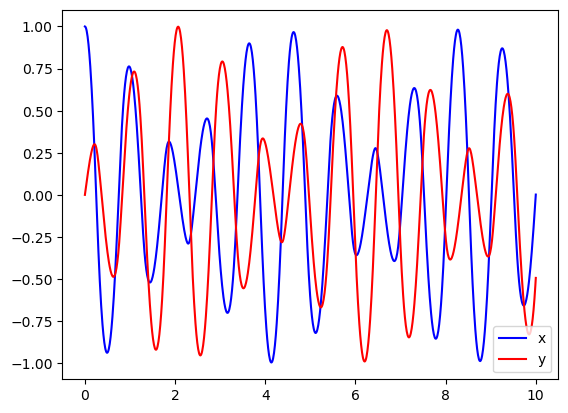

In [27]:
plt.figure()
plt.plot(sol.t,x,'b-',label='x')
plt.plot(sol.t,y,'r-',label='y')
plt.legend()
plt.show()

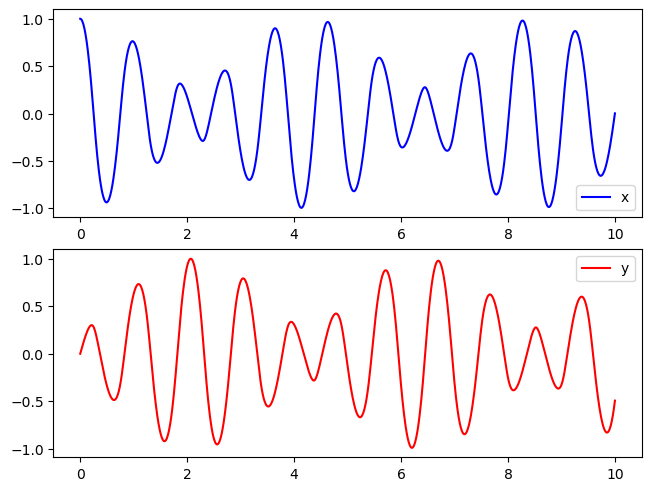

In [28]:
plt.subplots(2,1,layout='constrained')
plt.subplot(211)
plt.plot(sol.t,x,'b-',label='x')
plt.legend()
plt.subplot(212)
plt.plot(sol.t,y,'r-',label='y')
plt.legend()
plt.show()

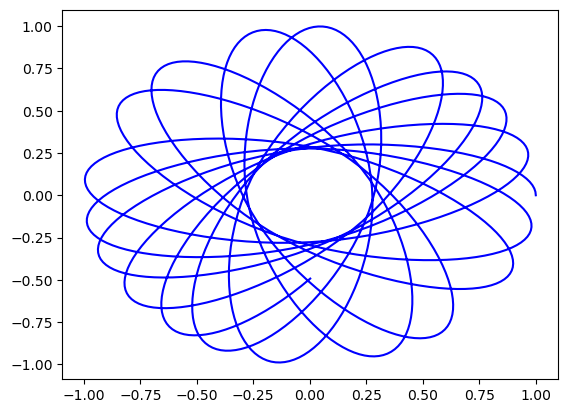

In [29]:
plt.figure()
plt.plot(x,y,'b-')
plt.show()

#### Example - Projectile motion

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  2.002e-03 ...  1.726e+00  1.728e+00]
        y: [[ 1.000e-08  2.401e-02 ...  1.464e+01  1.466e+01]
            [ 7.854e-01  7.848e-01 ...  1.410e-03  2.520e-04]
            [ 1.200e+01  1.199e+01 ...  8.473e+00  8.483e+00]
            [ 0.000e+00 -2.897e-01 ... -5.786e-01 -5.786e-01]]
      sol: None
 t_events: [array([ 1.728e+00])]
 y_events: [array([[ 1.466e+01,  1.908e-16,  8.485e+00, -5.786e-01]])]
     nfev: 494
     njev: 0
      nlu: 0


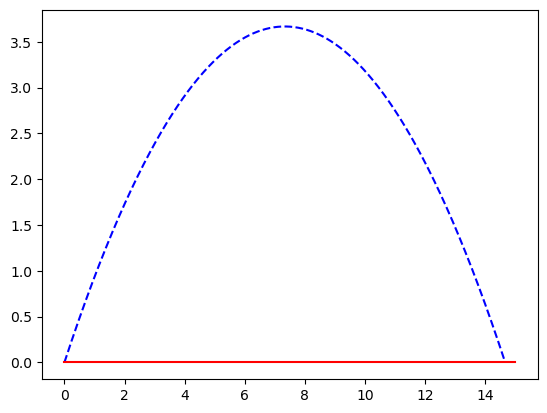

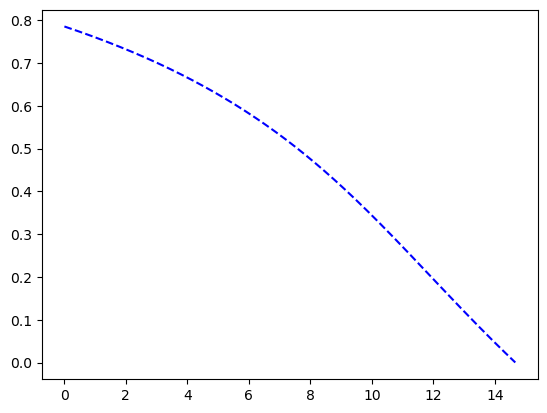

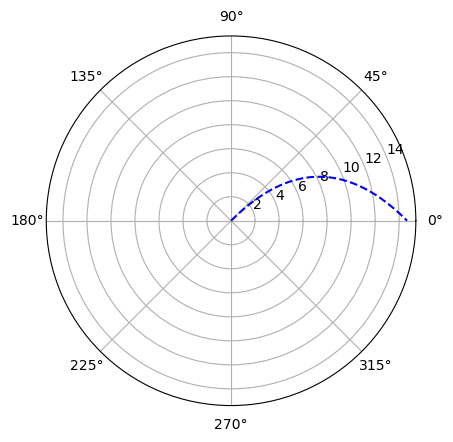

In [30]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 0.3
g = 9.82
t1 = 0.0
t2 = 2.0
N = 1000
def f(t,y):
    r,theta,v_r,omega = y
    F_r = -m*g*np.sin(theta)
    F_theta = -m*g*np.cos(theta)
    r_dot  = v_r
    theta_dot = omega
    v_r_dot = F_r/m+r*omega**2
    omega_dot = (F_theta/m-2*v_r*omega)/r
    return [r_dot,theta_dot,v_r_dot,omega_dot]

def zero(t,y):
    r,theta,v_r,omega = y
    return r * np.sin(theta) 
zero.direction = -1
zero.terminal = True
t = np.linspace(t1,t2,N)
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[0.00000001,np.pi/4.0,12.0,0.0],events=[zero],atol=1e-8,rtol=1e-8)
r = sol.y[0]
theta = sol.y[1]
x = r * np.cos(theta)
y = r * np.sin(theta)
print(sol)
plt.figure()
plt.plot(x,y,'b--')
plt.plot([0,15],[0,0],'r-')
plt.show()
plt.plot(r,theta,'b--')
plt.show()
plt.polar(theta,r,'b--')
plt.show()


#### Example - Central force proportional with square of distance (directed towards origin)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.002e-02 ...  1.998e+01  2.000e+01]
        y: [[ 2.000e+00  2.000e+00 ...  2.000e+00  2.000e+00]
            [ 0.000e+00  2.002e-03 ...  1.884e+01  1.885e+01]
            [ 0.000e+00 -4.605e-03 ...  1.378e-02  9.171e-03]
            [ 1.000e-01  1.000e-01 ...  1.000e-01  1.000e-01]]
      sol: None
 t_events: [array([ 3.295e+00])]
 y_events: [array([[ 1.600e-01,  1.571e+00, -2.300e+00,  1.563e+01]])]
     nfev: 2996
     njev: 0
      nlu: 0


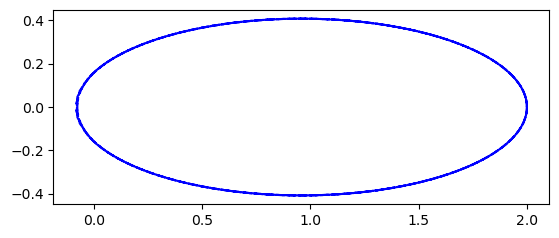

In [31]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 1.0
t1 = 0.0
t2 = 20.0
N = 1000
def f(t,y):
    r,theta,v_r,omega = y
    F_r = -r**-2
    F_theta = 0
    r_dot  = v_r
    theta_dot = omega
    v_r_dot = F_r/m+r*omega**2
    omega_dot = (F_theta/m-2*v_r*omega)/r
    return [r_dot,theta_dot,v_r_dot,omega_dot]
def zero(t,y):
    r,theta,r_dot,theta_dot = y
    return theta-np.pi/2 
zero.direction = +1
zero.terminal = False
t = np.linspace(t1,t2,N)
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[2,0.0,0.0,0.1],events=[zero],atol=1e-8,rtol=1e-8)
r = sol.y[0]
theta = sol.y[1]
x = r * np.cos(theta)
y = r * np.sin(theta)
print(sol)
plt.figure()
plt.axes().set_aspect('equal')
plt.plot(x,y,'b--')
plt.show()

#### Example - Pendulum - motion

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.005e-02 ...  1.990e+00  2.000e+00]
        y: [[ 8.727e-01  8.714e-01 ... -1.329e-01 -8.468e-02]
            [ 0.000e+00 -2.519e-01 ...  4.776e+00  4.812e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 626
     njev: 0
      nlu: 0


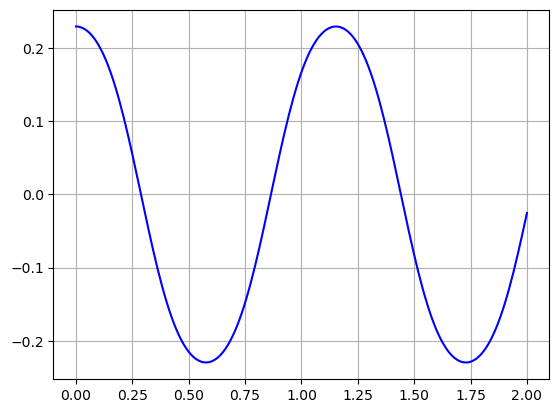

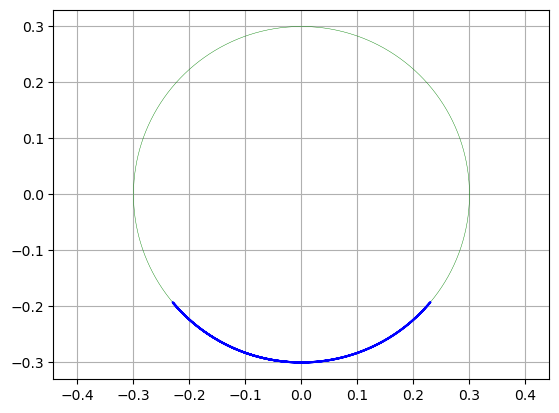

In [37]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 1.0
R = 0.3
t1 = 0.0
t2 = 2.0
N = 200
def f(t,y):
    theta,omega = y
    return [omega,-g/R*np.sin(theta)]
t = np.linspace(t1,t2,N)
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[50.0*np.pi/180.0,0.0],atol=1e-8,rtol=1e-8)
theta = sol.y[0]
x = R * np.sin(theta)
y = -R * np.cos(theta)
print(sol)
plt.figure()
plt.plot(t,x,'b-')
plt.grid(True)
plt.show()
T = np.linspace(0,2*np.pi,1000)
plt.plot(R*np.cos(T),R*np.sin(T),'g-',linewidth=0.3)
plt.plot(x,y,'b-')
plt.grid(True)
plt.axis('equal')
plt.show()

#### Example - Particle on spring in vertical plane


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.000e-03 ...  2.000e+01  2.000e+01]
        y: [[ 2.000e-01  2.035e-01 ...  9.376e-01  9.306e-01]
            [ 1.571e+00  1.561e+00 ... -1.292e+00 -1.289e+00]
            [ 1.732e+00  1.722e+00 ... -3.484e+00 -3.489e+00]
            [-5.000e+00 -4.832e+00 ...  1.725e+00  1.745e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 12590
     njev: 0
      nlu: 0


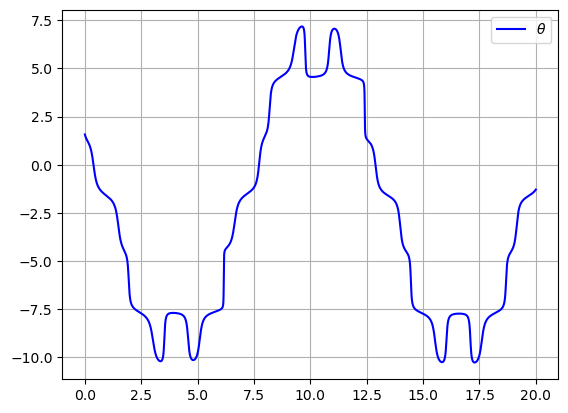

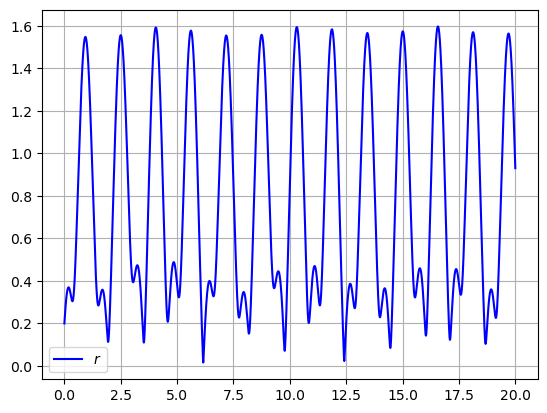

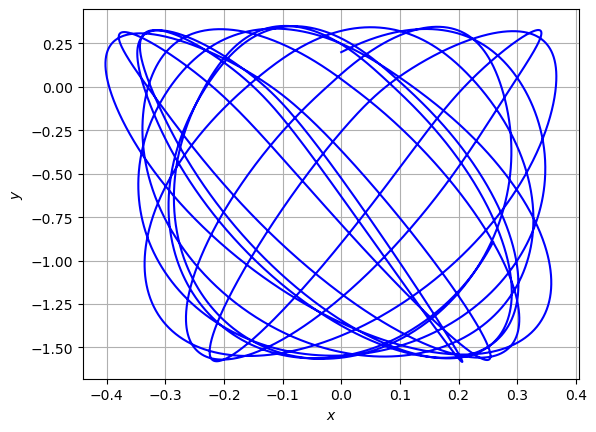

In [38]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
g = 9.82
m = 0.2
L0 = 0.2
k = 4.0
theta0 = 60*np.pi/180
v0 = 2.0
t1 = 0.0
t2 = 20.0
N = 10000
def f(t,y):
    r,theta,v_r,omega = y
    F_r = -k*(r-L0)-m*g*np.sin(theta)
    F_theta = -m*g*np.cos(theta)
    r_dot  = v_r
    theta_dot = omega
    v_r_dot = F_r/m+r*omega**2
    omega_dot = (F_theta/m-2*v_r*omega)/r
    return [r_dot,theta_dot,v_r_dot,omega_dot]
t = np.linspace(t1,t2,N)
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[L0,np.pi/2,v0*np.sin(theta0),-v0*np.cos(theta0)/L0],atol=1e-8,rtol=1e-8)
r = sol.y[0]
theta = sol.y[1]
x = r * np.cos(theta)
y = r * np.sin(theta)
print(sol)
plt.figure()
plt.plot(sol.t,theta,'b-',label=r'$\theta$')
plt.legend()
plt.grid(True)
plt.show()
plt.plot(sol.t,r,'b-',label='$r$')
plt.legend()
plt.grid(True)
plt.show()
plt.plot(x,y,'b-')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid(True)
plt.show()

#### Example - Pendulum - motion and tension in string

General equations.

$m\left(\ddot r-r\dot \theta^2\right)=F_r$

$m\left(r\ddot \theta+2\dot r\dot\theta\right)=F_\theta$

Insert weight and tension in string.

$m\left(\ddot r-r\dot \theta^2\right)=mg\cos(\theta)-S$

$m\left(r\ddot \theta+2\dot r\dot\theta\right)=-mg\sin(\theta)$

Insert that the radial compoment does not change.

$-mr\dot \theta^2=mg\cos(\theta)-S$

$mr\ddot \theta=-mg\sin(\theta)$

Simplify.

$S=mg\cos(\theta)+mr\dot \theta^2$

$\ddot \theta=-\frac{g}{r}\sin(\theta)$

The second equation is the equation of motion.
The first equation can be used to find the tension as a function of time.

$\dot \theta=\omega$

$\dot \omega=-\frac{g}{r}\sin(\theta)$

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.005e-02 ...  1.990e+00  2.000e+00]
        y: [[ 8.727e-01  8.714e-01 ... -1.329e-01 -8.468e-02]
            [ 0.000e+00 -2.519e-01 ...  4.776e+00  4.812e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 626
     njev: 0
      nlu: 0


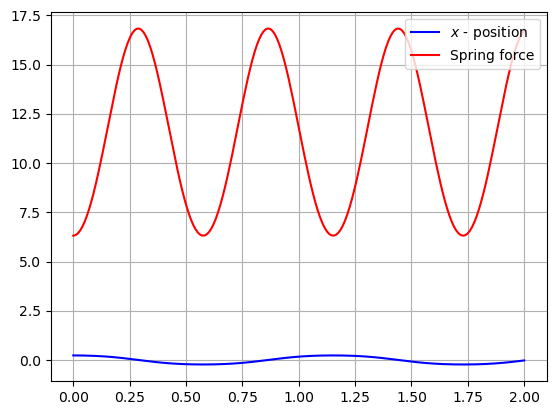

In [40]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
m = 1.0
R = 0.3
t1 = 0.0
t2 = 2.0
N = 200
def f(t,y):
    theta,omega = y
    return [omega,-g/R*np.sin(theta)]
t = np.linspace(t1,t2,N)
sol = solve_ivp(f,[t1,t2],t_eval=t,y0=[50.0*np.pi/180.0,0.0],atol=1e-8,rtol=1e-8)
theta = sol.y[0]
omega = sol.y[1]
x = R * np.sin(theta)
y = -R * np.cos(theta)
S = m*g*np.cos(theta)+m*R*omega**2
print(sol)
plt.figure()
plt.plot(t,x,'b-',label='$x$ - position')
plt.plot(t,S,'r-',label='Spring force')
plt.grid(True)
plt.legend()
plt.show()
